# Data Analysis
## Load Data
### Imports

In [25]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Data

In [4]:
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data')

ausgrid_complete_filepath = os.path.join(data_dir, 'ausgrid_complete.csv')
ausgrid_ppv_filepath = os.path.join(data_dir, 'ausgrid_ppv.csv')

# ausgrid_complete = pd.read_csv(ausgrid_complete_filepath)
ausgrid_ppv = pd.read_csv(ausgrid_ppv_filepath)

# Inspect data
print(f"Name: Ausgrid PPV Data")
print(f"Shape: {ausgrid_ppv.shape}")
print(f"Columns:", ausgrid_ppv.columns.tolist())
print(f"Missing values: {ausgrid_ppv.isna().sum().sum()}")
ausgrid_ppv.head()

Name: Ausgrid PPV Data
Shape: (15778212, 12)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'datetime', 'PPV', 'temperature_2m', 'wind_speed_10m', 'shortwave_radiation', 'cloud_cover', 'direct_normal_irradiance', 'diffuse_radiation', 'sunshine_duration']
Missing values: 0


,Customer,Generator Capacity,Postcode,datetime,PPV,temperature_2m,wind_speed_10m,shortwave_radiation,cloud_cover,direct_normal_irradiance,diffuse_radiation,sunshine_duration
0,1,3.78,2076,2010-07-01 00:00:00,0.0,3.60,8.30,0.0,1.0,0.0,0.0,0.0
1,1,3.78,2076,2010-07-01 00:30:00,0.0,3.45,8.35,0.0,5.0,0.0,0.0,0.0
2,1,3.78,2076,2010-07-01 01:00:00,0.0,3.30,8.40,0.0,9.0,0.0,0.0,0.0
3,1,3.78,2076,2010-07-01 01:30:00,0.0,2.75,8.45,0.0,15.5,0.0,0.0,0.0
4,1,3.78,2076,2010-07-01 02:00:00,0.0,2.20,8.50,0.0,22.0,0.0,0.0,0.0


## Characterize PPV time series

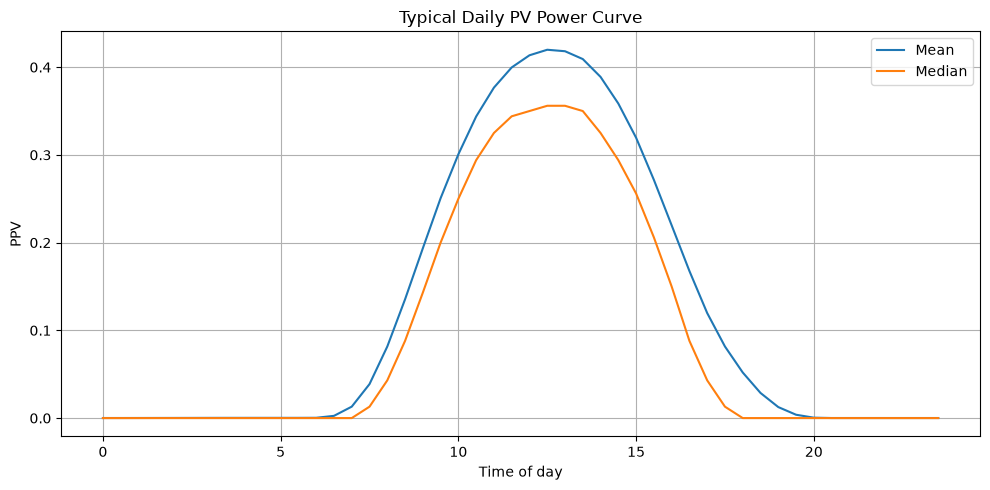

In [19]:
# Typical daily PPV curve
df = ausgrid_ppv.copy()
df["time"] = df["datetime"].dt.hour + df["datetime"].dt.minute / 60
daily_curve = df.groupby("time")["PPV"].agg(["mean", "median"])

plt.figure(figsize=(10, 5))
plt.plot(daily_curve.index, daily_curve["mean"], label="Mean")
plt.plot(daily_curve.index, daily_curve["median"], label="Median")
plt.xlabel("Time of day")
plt.ylabel("PPV")
plt.title("Typical Daily PV Power Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

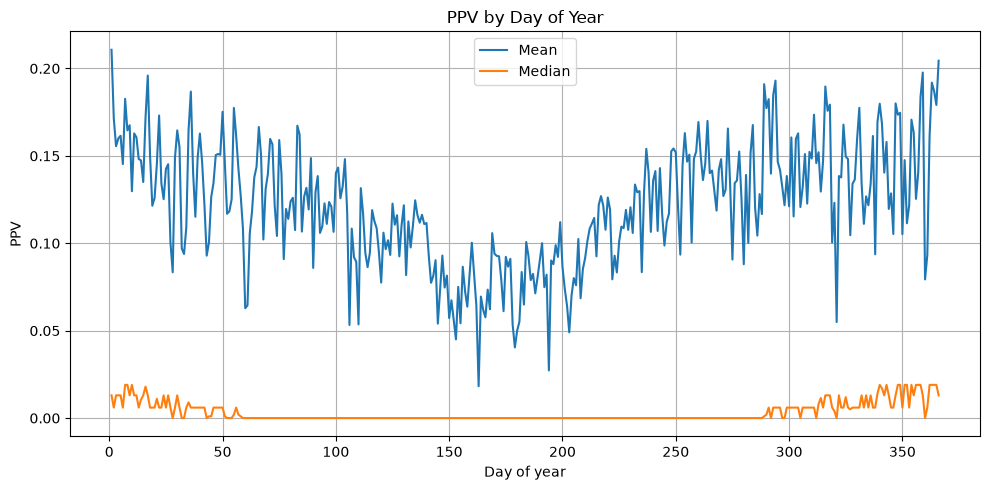

In [23]:
# Typical PPV by day of year
df["day_of_year"] = df["datetime"].dt.dayofyear
daily_curve = df.groupby("day_of_year")["PPV"].agg(["mean", "median"])

plt.figure(figsize=(10, 5))
plt.plot(daily_curve.index, daily_curve["mean"], label="Mean")
plt.plot(daily_curve.index, daily_curve["median"], label="Median")
plt.xlabel("Day of year")
plt.ylabel("PPV")
plt.title("PPV by Day of Year")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Baseline Models
### Simple Mean

In [26]:
# Mean baseline
y_true = ausgrid_ppv["PPV"].dropna()
y_pred = np.full(len(y_true), y_true.mean())

print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R²:", r2_score(y_true, y_pred))

MAE: 0.15885393750216514
RMSE: 0.24447507076458846
R²: 0.0


With an an MAE of 0.159 and an RMSE of 0.244, the mean is a weak predictor. As expected, $R^2=0$ because predicting the mean explains none of the variation in PPV. 

### Historical PV

We predict each PPV observation using the PPV recorded at the same date and time exactly one year earlier. 

In [35]:
# Historical baseline: PPV from exactly one year earlier for one customer
customer_id = ausgrid_ppv["Customer"].iloc[0]

df = ausgrid_ppv[ausgrid_ppv["Customer"] == customer_id][
    ["datetime", "PPV"]
].dropna().copy()

df["datetime"] = pd.to_datetime(df["datetime"])

ppv_lookup = df.drop_duplicates("datetime").set_index("datetime")["PPV"]

prev_dates = df["datetime"] - pd.DateOffset(years=1)
df["PPV_prev_year"] = ppv_lookup.reindex(prev_dates).to_numpy()

df = df.dropna(subset=["PPV_prev_year"])

print("Customer:", customer_id)
print("MAE:", mean_absolute_error(df["PPV"], df["PPV_prev_year"]))
print("RMSE:", np.sqrt(mean_squared_error(df["PPV"], df["PPV_prev_year"])))
print("R²:", r2_score(df["PPV"], df["PPV_prev_year"]))

Customer: 1
MAE: 0.14911613988086758
RMSE: 0.3210761293066749
R²: 0.4859198583646622


For this individual customer, the previous-year PPV is a much more useful baseline than the simple mean. MAE = 0.149 and RMSE = 0.322 indicate that reasonably large prediction errors remain. $R^2=0.489$ means the previous year's PPV explains about 49% of the variation in the current year's PPV. 

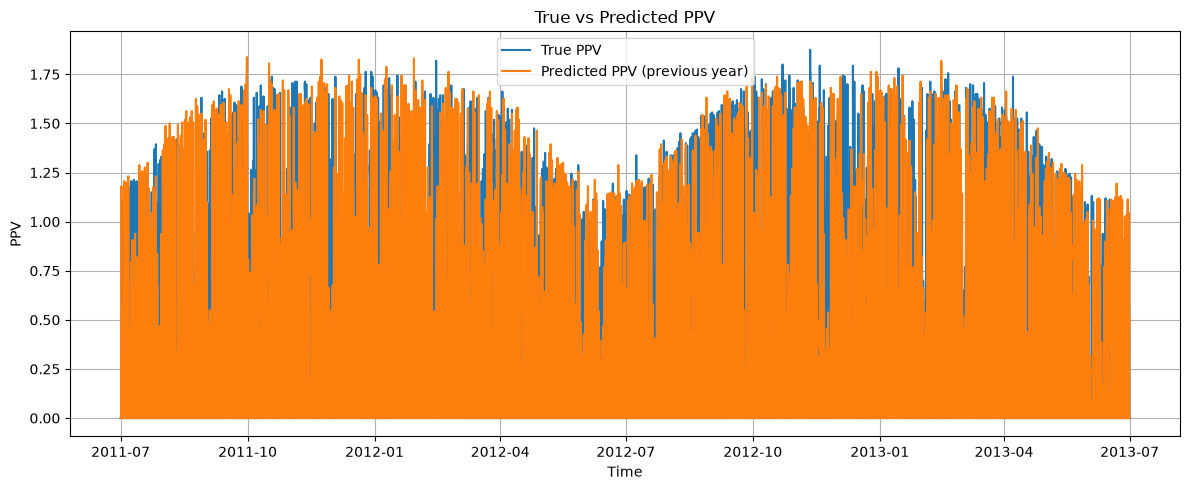

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(df["datetime"], df["PPV"], label="True PPV")
plt.plot(df["datetime"], df["PPV_prev_year"], label="Predicted PPV (previous year)")

plt.xlabel("Time")
plt.ylabel("PPV")
plt.title("True vs Predicted PPV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot shows that the previous year's data captures the overall seasonal pattern and approximate magnitude, bus misses much of the day-to-day variability, particularly weather-driven fluctuations.